# Colitis Ulcerative
## Sick vs Healthy prediction

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
# Loading the data
otu = pd.read_csv(
    "C:\\Users\\bruge\\OneDrive - University of Copenhagen\\2. år\\4. Metagenomic Analysis of Microbiome\\group-project-group-5\\project\\data\\D003093_Colitis,_Ulcerative\\genus\\otu_table.xls",
    sep="\t"
)

metadata = pd.read_csv(
    "C:\\Users\\bruge\\OneDrive - University of Copenhagen\\2. år\\4. Metagenomic Analysis of Microbiome\\group-project-group-5\\project\\data\\D003093_Colitis,_Ulcerative\\genus\\sample_data.xls",
    sep="\t"
)

In [3]:
# Preparing the data
otu = otu.set_index(otu.columns[0])

# Transposing
X = otu.T

In [4]:
# print column names of metadata
print(metadata.columns)

print(metadata['Disease.name'].value_counts())
print(metadata['Disease.MESH.ID'].value_counts())

#D006262 = raske
#D003093 = UC

Index(['#SampleID', 'Project.ID', 'Experiment.type', 'Nr..reads.sequenced',
       'Country', 'Sex', 'Host.age', 'BMI', 'Recent.antibiotics.use',
       'Disease.MESH.ID', 'Disease.name', 'QC.status'],
      dtype='object')
Disease.name
1    1066
Name: count, dtype: int64
Disease.MESH.ID
D006262    615
D003093    451
Name: count, dtype: int64


In [5]:
print(otu.columns)

Index(['ERR209057', 'ERR209058', 'ERR209059', 'ERR209060', 'ERR209061',
       'ERR209062', 'ERR209069', 'ERR209070', 'ERR209071', 'ERR209072',
       ...
       'SRR5983481', 'SRR5983484', 'SRR6876203', 'SRR6876204', 'SRR6876205',
       'SRR6876208', 'SRR6876210', 'SRR6876212', 'SRR6876223', 'SRR6876225'],
      dtype='object', length=1066)


In [6]:
metadata.head()

,#SampleID,Project.ID,Experiment.type,Nr..reads.sequenced,Country,Sex,Host.age,BMI,Recent.antibiotics.use,Disease.MESH.ID,Disease.name,QC.status
0,ERR209057,PRJEB1220,Metagenomics,7764468.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
1,ERR209058,PRJEB1220,Metagenomics,4465624.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
2,ERR209059,PRJEB1220,Metagenomics,9317812.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
3,ERR209060,PRJEB1220,Metagenomics,9644824.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
4,ERR209061,PRJEB1220,Metagenomics,9615221.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1


In [7]:
# count unique counts of Disease.MESH.ID in denmark, usa, spain (Country column)
print("Count of sick and healthy in Denmark:")
print(metadata[metadata['Country'] == 'Denmark']['Disease.MESH.ID'].value_counts())

print("Count of sick and healthy in USA:")
print(metadata[metadata['Country'] == 'United States of America']['Disease.MESH.ID'].value_counts())

print("Count of sick and healthy in Spain:")
print(metadata[metadata['Country'] == 'Spain']['Disease.MESH.ID'].value_counts())

Count of sick and healthy in Denmark:
Disease.MESH.ID
D006262    444
Name: count, dtype: int64
Count of sick and healthy in USA:
Disease.MESH.ID
D003093    138
D006262     55
Name: count, dtype: int64
Count of sick and healthy in Spain:
Disease.MESH.ID
D003093    223
D006262    116
Name: count, dtype: int64


In [8]:
metadata = metadata.dropna(subset=["Country"])

metadata = metadata[metadata["Country"] != "Denmark"]

print(metadata["Country"].value_counts())
print(metadata.shape)

Country
Spain                       339
United States of America    193
Name: count, dtype: int64
(532, 12)


In [9]:
# Preparing column names
metadata = metadata.reset_index(drop=True)

target_col = "Disease.MESH.ID"

metadata = metadata.set_index("#SampleID")

# Match metadata to OTU samples
common_samples = metadata.index.intersection(X.index)
metadata = metadata.loc[common_samples]
X = X.loc[common_samples]

y = metadata[target_col]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [10]:
# Data split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
print(X_train.shape, y_train.shape)

(425, 78) (425,)


In [12]:
# Prediction
y_pred = model.predict(X_test)

In [13]:
# Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88        73
           1       0.80      0.59      0.68        34

    accuracy                           0.82       107
   macro avg       0.81      0.76      0.78       107
weighted avg       0.82      0.82      0.81       107



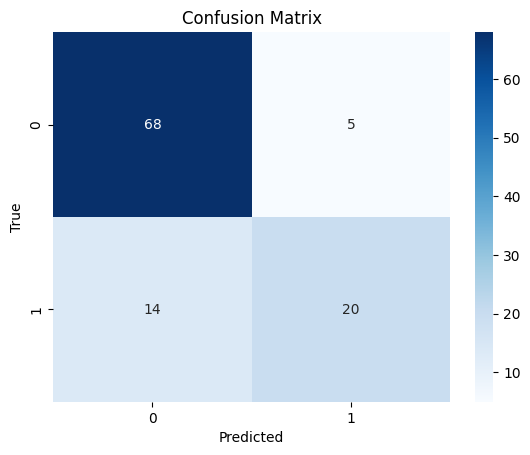

In [14]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

#categorical = ["Country", "Sex", "Recent.antibiotics.use"]

#numeric = ["Host.age", "BMI"]

# preprocessor = ColumnTransformer(
    #transformers=[
     #   ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
      #  ("num", StandardScaler(), numeric)
    #])


country = ["Country"]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), country)
    ]
)

In [29]:
X_full = pd.concat(
    [X, metadata[country]],
    axis=1
)

X_full.columns = X_full.columns.astype(str)

In [30]:
X_full_encoded = pd.get_dummies(
    X_full,
    columns=["Country"], #"Sex", "Recent.antibiotics.use"
    dummy_na=True
)

In [31]:
X_full_encoded.columns = X_full_encoded.columns.astype(str)

X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(
    X_full_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

model_meta = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_meta.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
# Prediction
y_pred = model_meta.predict(X_test)

In [33]:
# Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.96      0.90        73
           1       0.88      0.65      0.75        34

    accuracy                           0.86       107
   macro avg       0.87      0.80      0.82       107
weighted avg       0.86      0.86      0.85       107



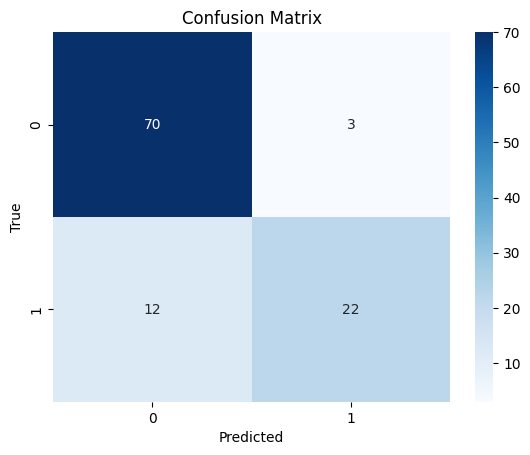

In [34]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()